In [ ]:
import csv
import re

def read_data(file):
    data = {}
    with open(file, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile, delimiter='\t')
        for row in reader:
            century = float(row[0])
            if 17 <= century <= 20:
                word = row[1]
                frequency = float(row[2])
                if century not in data:
                    data[century] = {}
                if word not in data[century]:
                    data[century][word] = frequency
                else:
                    data[century][word] += frequency
    return data


def calculate_category_frequency(data, categories):
    category_frequency = {}
    for century, words in data.items():
        for word, frequency in words.items():
            for category, category_words in categories.items():
                if word in category_words:
                    if category not in category_frequency:
                        category_frequency[category] = {}
                    if century not in category_frequency[category]:
                        category_frequency[category][century] = frequency
                    else:
                        category_frequency[category][century] += frequency
    return category_frequency


def calculate_relative_frequency(category_frequency):
    for category, data in category_frequency.items():
        total = sum(data.values())
        for century, frequency in data.items():
            category_frequency[category][century] = frequency / total
    return category_frequency


def print_relative_frequency(category_frequency):
    for category, data in category_frequency.items():
        print(f"Relative frequency for the category '{category}':")
        for century, frequency in data.items():
            print(f"Century {century-1}: {frequency:.2%}")
        print()


categories = {
    # 'smell/odour': ['scent', 'smell', 'fmell', 'smelle', 'snuff', 'odour', 'odor', 'savour', 'breath', 'fume', 'effluvium', 'smack', 'reflair', 'smelling', 'flavour', 'verdure', 'senteur', 'waft', 'weft', 'fluor', 'fumet', 'aura', 'snuff', 'waff', 'olfacient', 'odouret', 'gush', 'sniff', 'tang', 'nose', 'odoriferent', 'odorant', 'odourousness', 'odorosity', 'savouring', 'odorant', 'scenter', 'gale', 'parosmia', 'parosmis', 'osmatism', 'sneving', 'snoking', 'vent', 'venting', 'olfaction', 'scenting', 'stooping', 'odoriferous', 'odorous', 'olfactory', 'odoured', 'smellable', 'reflairing', 'odoriferant', 'scenting', 'savouring', 'odorable', 'olent', 'smelled', 'tainted', 'odorific', 'odourful', 'osmic', 'olfactible', 'sniffable', 'olfactive', 'olfactory', 'scentful', 'snokey'],
    
    'stench/stinking': ['stink', 'stinch', 'stench', 'reek', 'whiff', 'fetor', 'foetor', 'redolence', 'pong', 'niff', 'pungency', 'stinking', 'malodorous', 'fetid', 'foetid', 'niffy', 'smelly', 'reeking', 'whiffy', 'pungent', 'noisome', 'funky', 'musty', 'frowzy', 'stinkingness', 'staunch', 'dain', 'fetidness', 'pungence', 'fetidity', 'malodorousness', 'smelliness', 'niffiness', 'stinkard', 'stinker', 'stink-pot', 'fustiness', 'mustiness', 'foistiness', 'frowziness', 'foist', 'frowstiness', 'stew', 'fist', 'funk', 'stanch', 'hogo', 'fogo', 'styth', 'malodour', 'ponk', 'taint', 'halitosis', 'nidor', 'nidorosity', 'mephitis', 'rammish', 'poignant', 'reeky', 'ugly', 'rank', 'ranke', 'unsavoury', 'nasty', 'noisome', 'fulsome', 'rammy', 'stinkardly', 'stenchful', 'rancid', 'olidous', 'stenching', 'maleolent', 'graveolent', 'virous', 'olid', 'rancidous', 'feculent', 'virose', 'stenchy', 'infragrant', 'nosey', 'unfragrant', 'cacodorous', 'stinky', 'pongy', 'fusty', 'foisty', 'fusted', 'foughty', 'frowsty', 'rafty', 'foisted', 'frowsty'],
    
    'fragrance/fragrant': ['redolence', 'perfume', 'scent', 'aroma', 'fragrance', 'musk', 'aroma', 'perfume', 'fume', 'scented', 'aromatic', 'fragrant', 'redolent', 'sweet', 'fragrancy', 'odoriferousness', 'sweetness', 'fragrantness', 'muskiness', 'aromaticness', 'balsamicness', 'redolency', 'soot', 'petrichor', 'perfuming', 'sweetening', 'aromatization', 'aromatizing', 'ambering', 'scenting', 'essence', 'luscious', 'flagrant', 'balmy', 'perfumed', 'aromatical', 'essenced', 'flavorous', 'flavouriferous', 'aromal', 'perfumy', 'euodic', 'scenty', 'perfumatory'],
    
    'lacking_odour': ['odourless', 'odorless', 'scentless', 'unscented', 'deodorized', 'deodorization', 'deodorizer', 'deodorant', 'unsmelling', 'savourless', 'inodorate', 'vapid', 'unfetid', 'unsmelt', 'perfumeless', 'incenseless', 'unsmelled', 'deodorizing', 'inolfacient']
}

data = read_data('smell_cent_no_col.tsv')

category_frequency = calculate_category_frequency(data, categories)
relative_category_frequency = calculate_relative_frequency(category_frequency)

print_relative_frequency(relative_category_frequency)

Relative frequency for the category 'stench/stinking':
Century 16.0: 48.27%
Century 17.0: 18.36%
Century 18.0: 20.95%
Century 19.0: 12.42%

Relative frequency for the category 'fragrance/fragrant':
Century 16.0: 17.51%
Century 17.0: 21.74%
Century 18.0: 28.97%
Century 19.0: 31.78%

Relative frequency for the category 'lacking_odour':
Century 16.0: 0.27%
Century 17.0: 1.50%
Century 18.0: 34.59%
Century 19.0: 63.64%



In [8]:
def calculate_relative_word_frequency_per_century(data, categories):
    word_frequency_per_century = {}

    
    for category, category_words in categories.items():
        for word in category_words:
            if word not in word_frequency_per_century:
                word_frequency_per_century[word] = {}
            for century in range(17, 21):
                if century not in word_frequency_per_century[word]:
                    word_frequency_per_century[word][century] = 0

    
    for century, words in data.items():
        for word, frequency in words.items():
            for category, category_words in categories.items():
                if word in category_words:
                    word_frequency_per_century[word][century] += frequency

    
    for word, century_frequencies in word_frequency_per_century.items():
        word_total = sum(century_frequencies.values())
        for century, frequency in century_frequencies.items():
            if word_total != 0:
                word_frequency_per_century[word][century] = frequency / word_total

    return word_frequency_per_century

def print_relative_word_frequency_per_century(word_frequency_per_century, categories):
    for category, category_words in categories.items():
        print(f"Category: {category}"+'\n')
        for word in category_words:
            print(f"Relative frequency for the word '{word}':")
            for century, frequency in word_frequency_per_century[word].items():
                print(f"    Century {century-1}: {frequency:.2%}")
            print()


word_frequency_per_century = calculate_relative_word_frequency_per_century(data, categories)
print_relative_word_frequency_per_century(word_frequency_per_century, categories)

Category: stench/stinking

Relative frequency for the word 'stink':
    Century 16: 82.13%
    Century 17: 2.89%
    Century 18: 8.36%
    Century 19: 6.62%

Relative frequency for the word 'stinch':
    Century 16: 99.72%
    Century 17: 0.00%
    Century 18: 0.28%
    Century 19: 0.00%

Relative frequency for the word 'stench':
    Century 16: 47.15%
    Century 17: 2.79%
    Century 18: 31.19%
    Century 19: 18.87%

Relative frequency for the word 'reek':
    Century 16: 20.72%
    Century 17: 19.48%
    Century 18: 38.17%
    Century 19: 21.63%

Relative frequency for the word 'whiff':
    Century 16: 8.15%
    Century 17: 7.66%
    Century 18: 46.04%
    Century 19: 38.15%

Relative frequency for the word 'fetor':
    Century 16: 4.64%
    Century 17: 35.92%
    Century 18: 40.43%
    Century 19: 19.01%

Relative frequency for the word 'foetor':
    Century 16: 33.00%
    Century 17: 18.36%
    Century 18: 41.49%
    Century 19: 7.15%

Relative frequency for the word 'redolence':

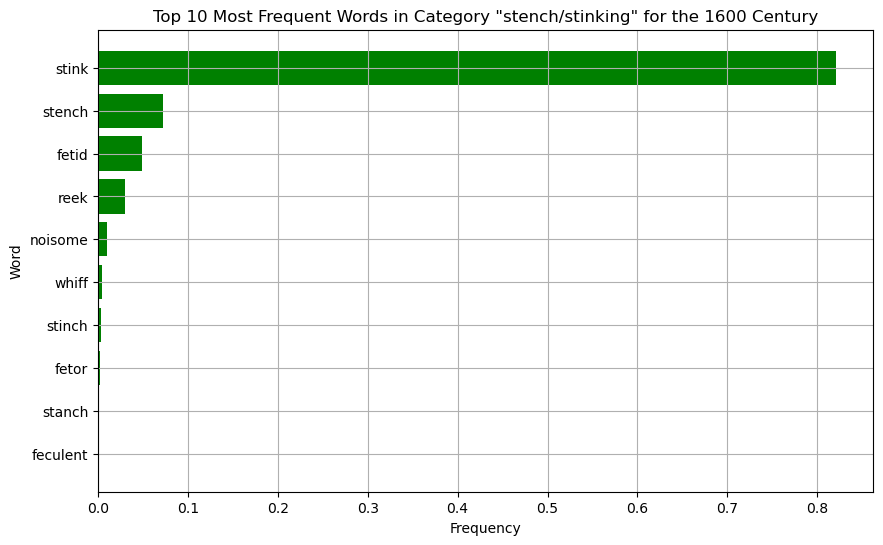

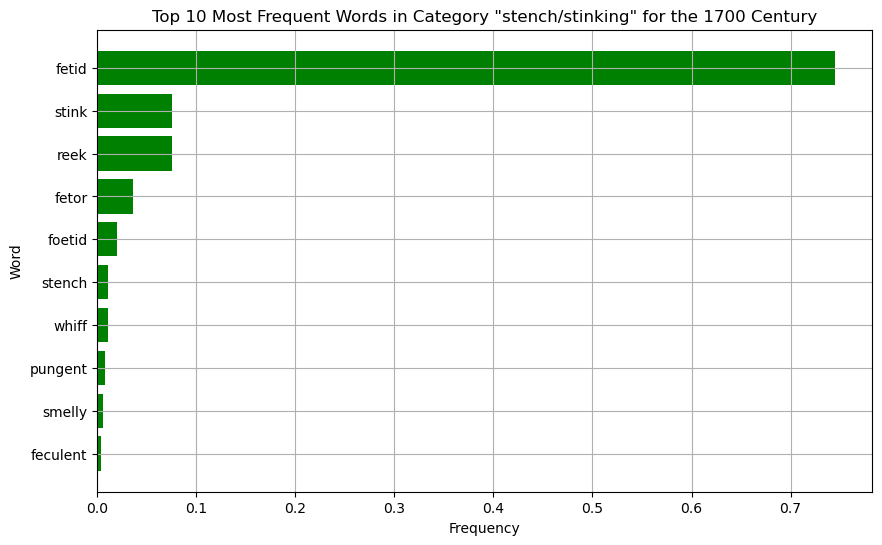

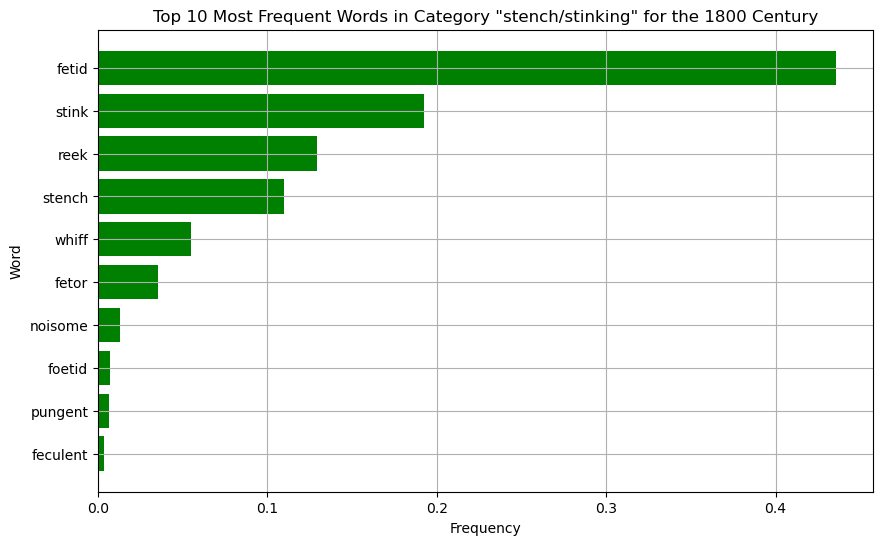

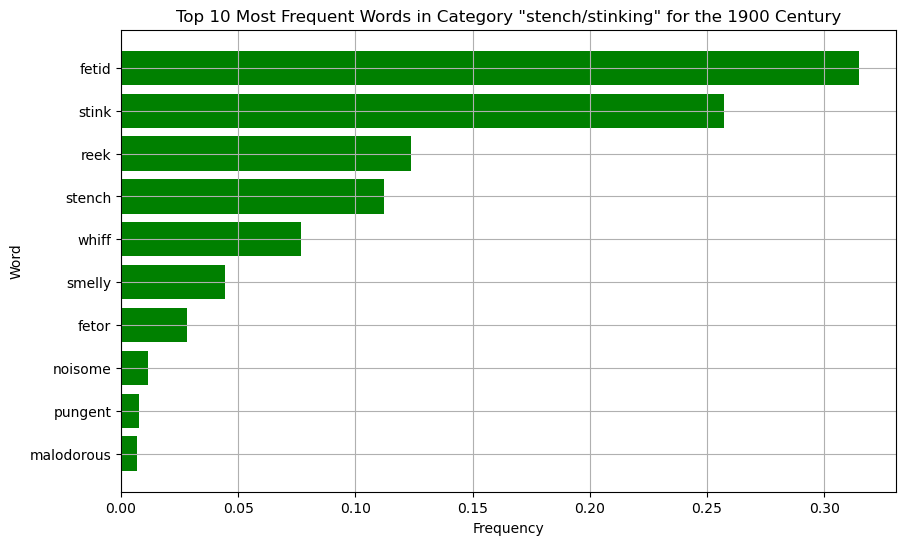

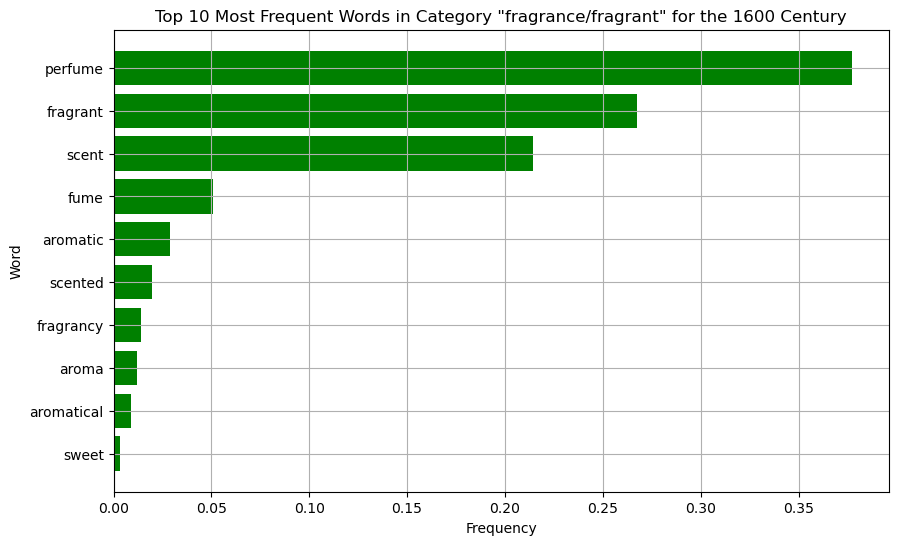

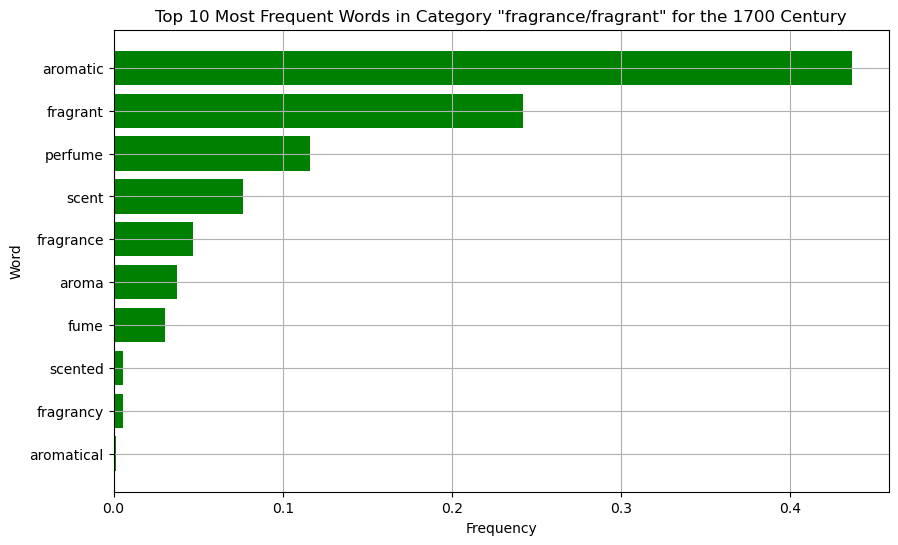

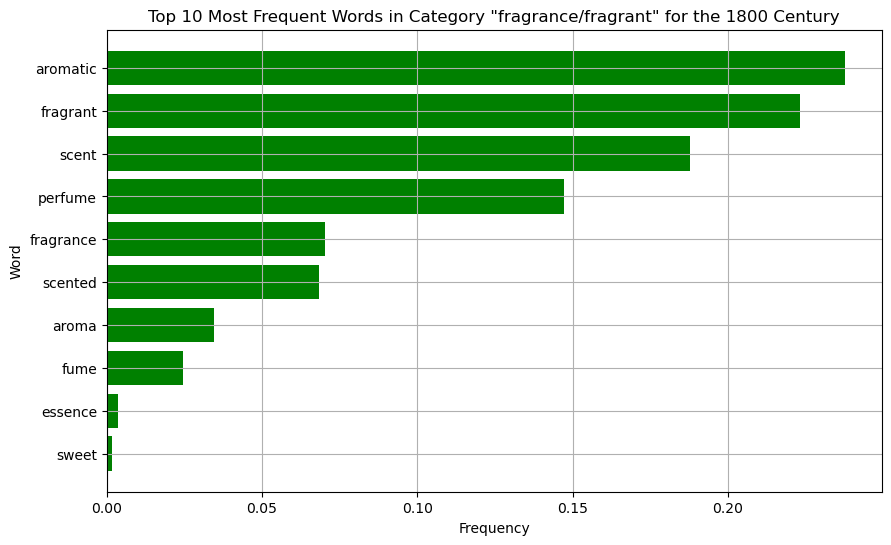

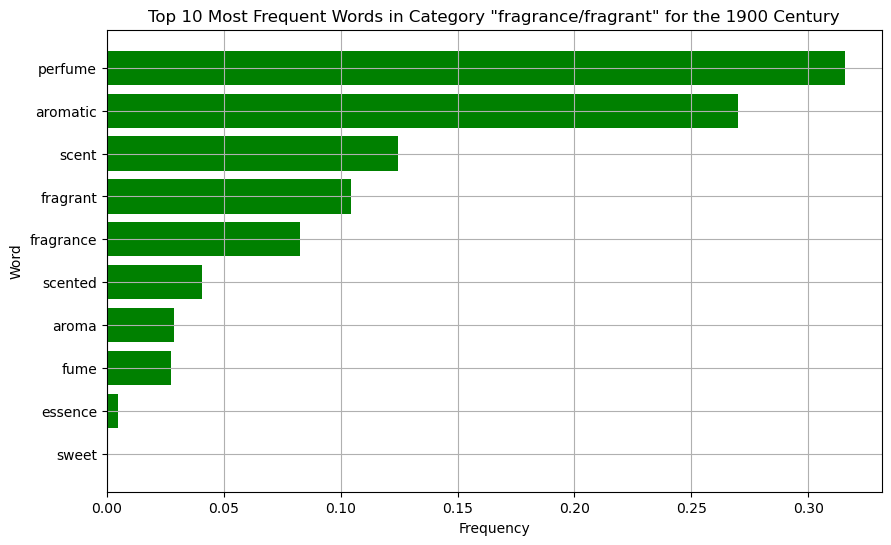

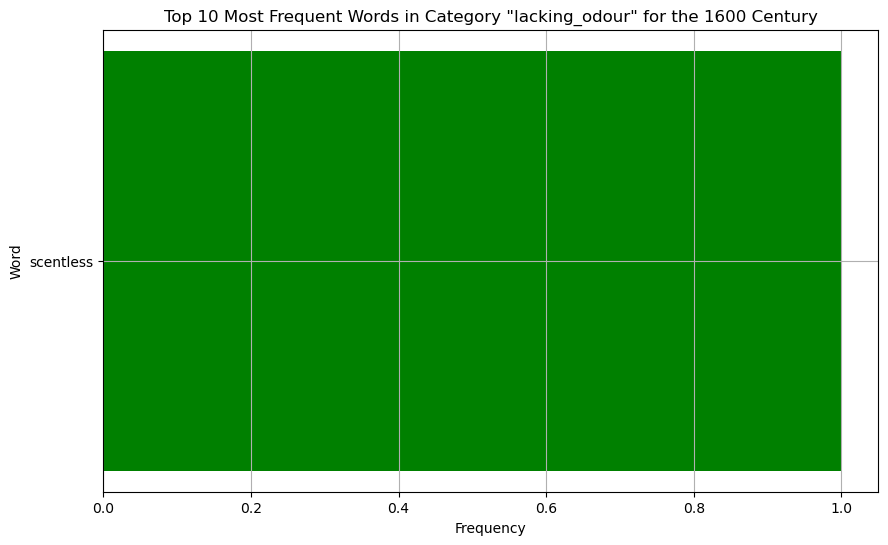

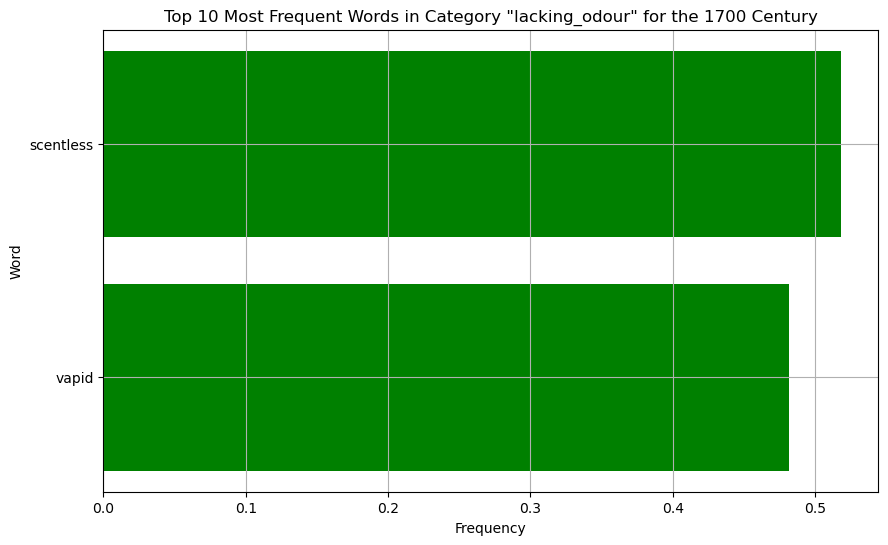

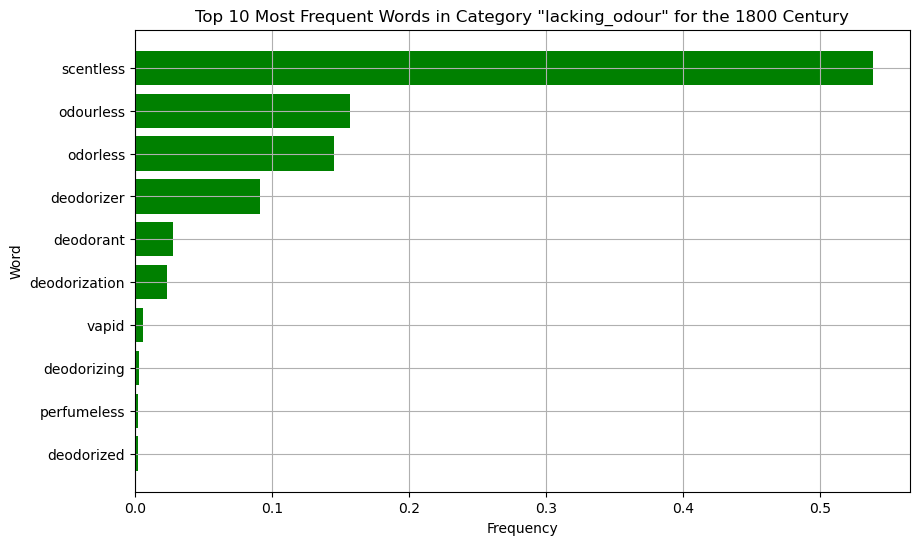

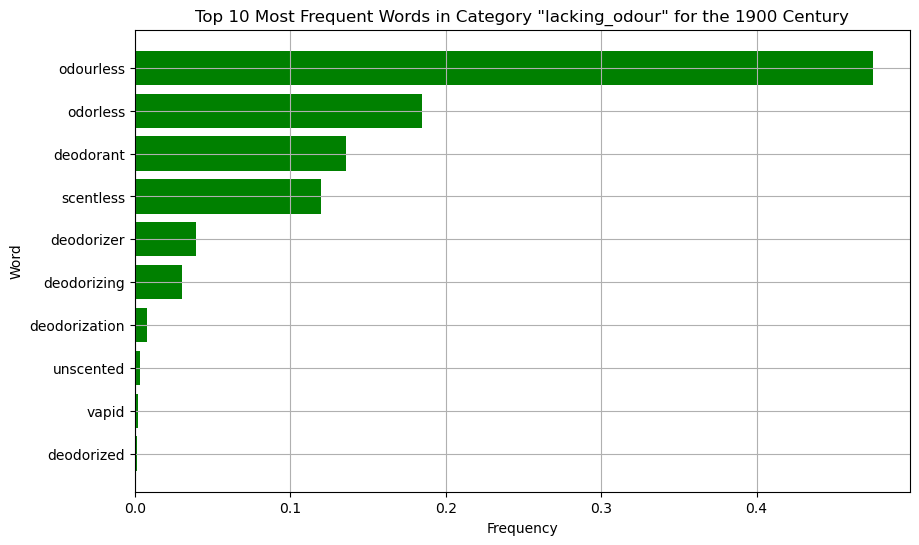

In [ ]:

import matplotlib.pyplot as plt

def plot_top_words_per_category_normalized(data, categories, top_n=10):
    for category, category_words in categories.items():
        for century, words in data.items():
            # century = str(century).replace('.0', '00')
            category_words_century = {word: frequency for word, frequency in words.items() if word in category_words}
            total_frequencies = sum(category_words_century.values())
            sorted_words = sorted(category_words_century.items(), key=lambda x: x[1], reverse=True)[:top_n]

            
            top_words = [word[0] for word in sorted_words]
            top_frequencies = [word[1] / total_frequencies for word in sorted_words]  # Frequency normalization

            
            plt.figure(figsize=(10, 6))
            plt.barh(top_words, top_frequencies, color='green')
            plt.xlabel('Frequency')
            plt.ylabel('Word')
            plt.title(f'Top {top_n} Most Frequent Words in Category "{category}" for the {int(century-1)}00 Century')
            plt.gca().invert_yaxis()
            plt.grid(True)
            plt.show()


plot_top_words_per_category_normalized(data, categories, top_n=10)